# 02 - Exploratory Data Analysis (EDA)
### AI-Powered Predictive Bed Demand Forecasting - Albion Care Network

**Notebook 2 of 7** | Data Foundation Phase

---

## Objectives

1. Characterise bed-demand trend, weekly patterns, and seasonality across the network.
2. Analyse admissions, discharges, ED/outpatient arrivals, elective surgery, and staffing
   individually, identifying operational bottlenecks in each.
3. Quantify the relationships between admissions, occupancy, staffing, surgeries, and
   discharge patterns that Notebook 03 will turn into predictive features.
4. Identify anomalies and known data artefacts (e.g. the simulation burn-in period found in
   Notebook 01) that must be handled before modelling.
5. Produce clear, non-technical business insights and export summary tables that a Power BI
   dashboard can consume directly.

## Background

Notebook 01 delivered six clean, consistent datasets. This notebook turns that clean data into
understanding: where and when bed demand is highest, what drives it, and which operational
levers (staffing, discharge destinations, ED conversion, surgery cancellations) are most
strongly associated with capacity pressure. Every finding here is intended to be read by both
a data scientist building the forecasting models in Notebooks 03-05, and a hospital operations
manager who needs the plain-English implication.

## Inputs

The six cleaned datasets produced by Notebook 01 (`data/processed/*_clean.parquet`).

## Outputs

- A set of business-ready summary tables in `data/processed/eda_exports/` for Power BI.
- The insights and data-quality caveats (e.g. burn-in period) that Notebook 03's feature
  engineering must account for.


In [1]:
# --- Setup & configuration -------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROC_DIR = Path('../data/processed')
EXPORT_DIR = PROC_DIR / 'eda_exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

hospital_ref = pd.read_parquet(PROC_DIR / 'hospital_reference_clean.parquet')
adm = pd.read_parquet(PROC_DIR / 'admissions_discharges_clean.parquet')
bed = pd.read_parquet(PROC_DIR / 'bed_inventory_occupancy_clean.parquet')
ed = pd.read_parquet(PROC_DIR / 'ed_outpatient_arrivals_clean.parquet')
surg = pd.read_parquet(PROC_DIR / 'elective_surgery_schedule_clean.parquet')
staff = pd.read_parquet(PROC_DIR / 'staffing_resource_clean.parquet')

# Attach readable hospital attributes wherever a hospital_id appears.
adm = adm.merge(hospital_ref, on='hospital_id', how='left')
bed = bed.merge(hospital_ref, on='hospital_id', how='left')
ed = ed.merge(hospital_ref, on='hospital_id', how='left')
surg = surg.merge(hospital_ref, on='hospital_id', how='left')
staff = staff.merge(hospital_ref, on='hospital_id', how='left')

print('admissions_discharges:', adm.shape)
print('bed_inventory_occupancy:', bed.shape)
print('ed_outpatient_arrivals:', ed.shape)
print('elective_surgery_schedule:', surg.shape)
print('staffing_resource:', staff.shape)


admissions_discharges: (130760, 18)
bed_inventory_occupancy: (701760, 15)
ed_outpatient_arrivals: (361975, 14)
elective_surgery_schedule: (25355, 14)
staffing_resource: (116960, 12)


---
## Section 1 - System-Wide Bed Demand: Trend and Seasonality

Bed occupancy is the core target variable for Notebooks 03-05, so we start here.


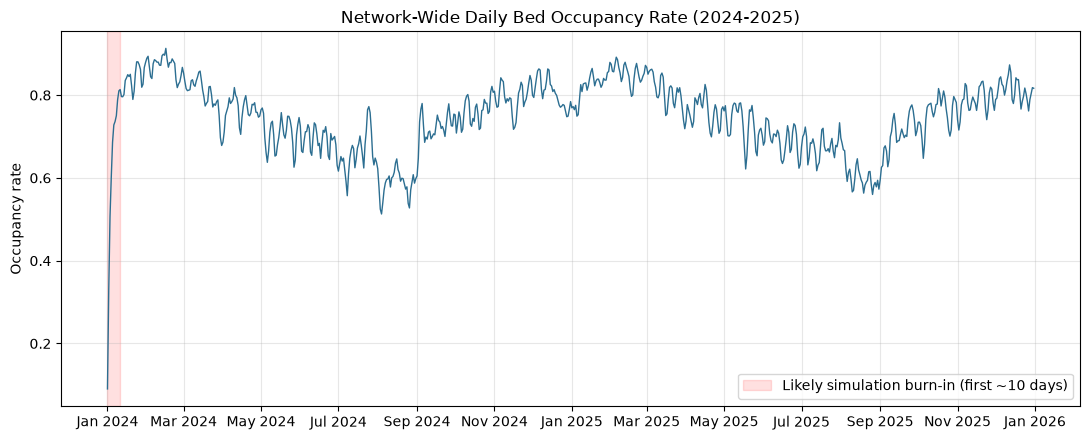

count    731.000000
mean       0.746517
std        0.085751
min        0.090261
25%        0.697115
50%        0.760280
75%        0.810257
max        0.912993
Name: occupancy_rate, dtype: float64


In [2]:
daily_occ = (
    bed.groupby(bed['datetime'].dt.date)
       .apply(lambda d: pd.Series({
           'occupied_beds': d['occupied_beds'].sum(),
           'staffed_beds': d['staffed_beds'].sum(),
       }), include_groups=False)
       .reset_index()
       .rename(columns={'datetime': 'date'})
)
daily_occ['date'] = pd.to_datetime(daily_occ['date'])
daily_occ['occupancy_rate'] = daily_occ['occupied_beds'] / daily_occ['staffed_beds']

fig, ax = plt.subplots()
ax.plot(daily_occ['date'], daily_occ['occupancy_rate'], linewidth=1, color='#2c6e91')
ax.axvspan(daily_occ['date'].min(), daily_occ['date'].min() + pd.Timedelta(days=10),
           color='red', alpha=0.12, label='Likely simulation burn-in (first ~10 days)')
ax.set_title('Network-Wide Daily Bed Occupancy Rate (2024-2025)')
ax.set_ylabel('Occupancy rate')
ax.legend(loc='lower right')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

print(daily_occ['occupancy_rate'].describe())


**Finding: simulation burn-in period.** Occupancy starts at 9% on 1 Jan 2024 and climbs
steadily to a stable ~75-80% band by roughly 11 Jan 2024. This is not a real operational event
(no corresponding spike in admissions or ED arrivals coincides with it); it is an artefact of
how the underlying dataset was generated, with every ward starting empty. **Notebook 03 should
exclude the first 10 days of 2024 from model training**, since including it would teach a
forecasting model a "ramp-up" pattern that will never recur in production data.

Excluding that window, occupancy is stable and bounded (25th-75th percentile of roughly
70%-81%), with a maximum of 91%, which suggests the network operates close to capacity for
extended periods rather than only during rare spikes.


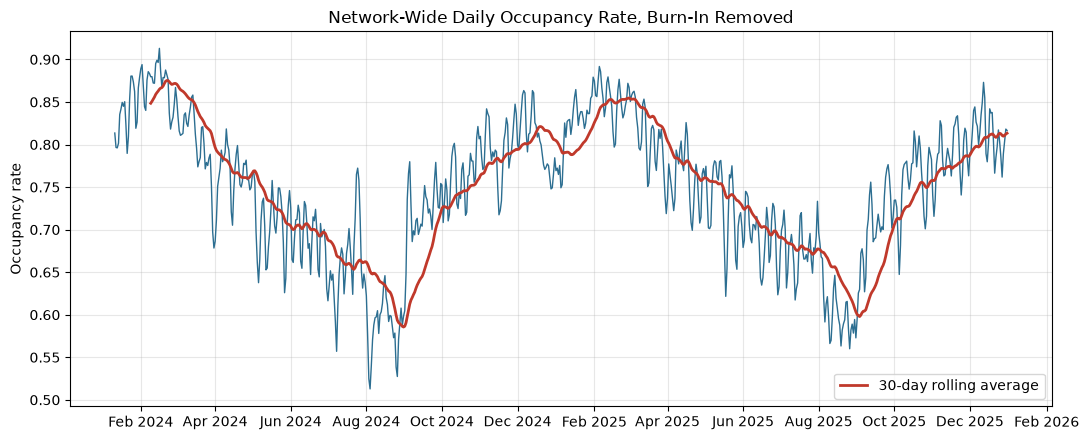

In [3]:
# All further analysis in this notebook excludes the burn-in window identified above.
BURN_IN_END = pd.Timestamp('2024-01-11')
bed_steady = bed[bed['datetime'] >= BURN_IN_END].copy()
daily_occ_steady = daily_occ[daily_occ['date'] >= BURN_IN_END].copy()

fig, ax = plt.subplots()
ax.plot(daily_occ_steady['date'], daily_occ_steady['occupancy_rate'], linewidth=1, color='#2c6e91')
ax.plot(daily_occ_steady['date'], daily_occ_steady['occupancy_rate'].rolling(30).mean(),
        linewidth=2, color='#c0392b', label='30-day rolling average')
ax.set_title('Network-Wide Daily Occupancy Rate, Burn-In Removed')
ax.set_ylabel('Occupancy rate')
ax.legend(loc='lower right')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()


**Finding: clear annual seasonality.** The 30-day rolling average shows two winter peaks
(around Jan-Feb 2024 and Dec 2024-Jan 2025) and a consistent summer trough (around Jul-Aug),
repeating across both years in the dataset. This matches the "seasonal illness" driver called
out in the business problem and is a strong candidate seasonal feature for Notebook 03.


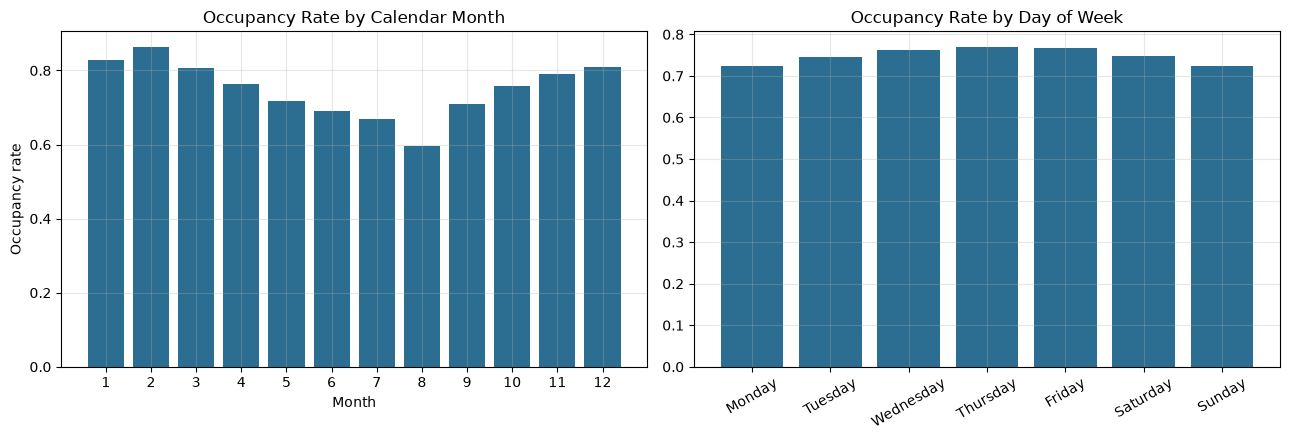

Peak month: 2 (86.3%)
Trough month: 8 (59.7%)

Day-of-week occupancy:
dow
Monday       0.724495
Tuesday      0.745761
Wednesday    0.762195
Thursday     0.768872
Friday       0.766596
Saturday     0.747985
Sunday       0.723141
dtype: float64


In [4]:
bed_steady['month'] = bed_steady['datetime'].dt.month
bed_steady['dow'] = bed_steady['datetime'].dt.day_name()
bed_steady['hour'] = bed_steady['datetime'].dt.hour
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

month_occ = (bed_steady.groupby('month').apply(
    lambda d: d['occupied_beds'].sum() / d['staffed_beds'].sum(), include_groups=False))
dow_occ = (bed_steady.groupby('dow').apply(
    lambda d: d['occupied_beds'].sum() / d['staffed_beds'].sum(), include_groups=False)).reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(month_occ.index, month_occ.values, color='#2c6e91')
axes[0].set_title('Occupancy Rate by Calendar Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Occupancy rate')
axes[0].set_xticks(range(1, 13))

axes[1].bar(dow_occ.index, dow_occ.values, color='#2c6e91')
axes[1].set_title('Occupancy Rate by Day of Week')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('Peak month:', month_occ.idxmax(), f'({month_occ.max():.1%})')
print('Trough month:', month_occ.idxmin(), f'({month_occ.min():.1%})')
print('\nDay-of-week occupancy:')
print(dow_occ)


**Finding: weekday/weekend pattern.** Occupancy is consistently higher Tuesday-Friday
and lower on weekends, which is the classic signature of elective activity (which mostly
happens on weekdays) layered on top of a steady emergency baseline. Hour-of-day occupancy
(checked below) is far flatter, since once a patient occupies a bed they typically stay
occupying it across the day. This means daily and weekly granularity carry most of the
useful signal for bed-demand forecasting, while hour-of-day is more useful for ED arrival
and staffing-shift forecasting specifically.


---
## Section 2 - Capacity Analysis by Ward, Bed Type, and Hospital


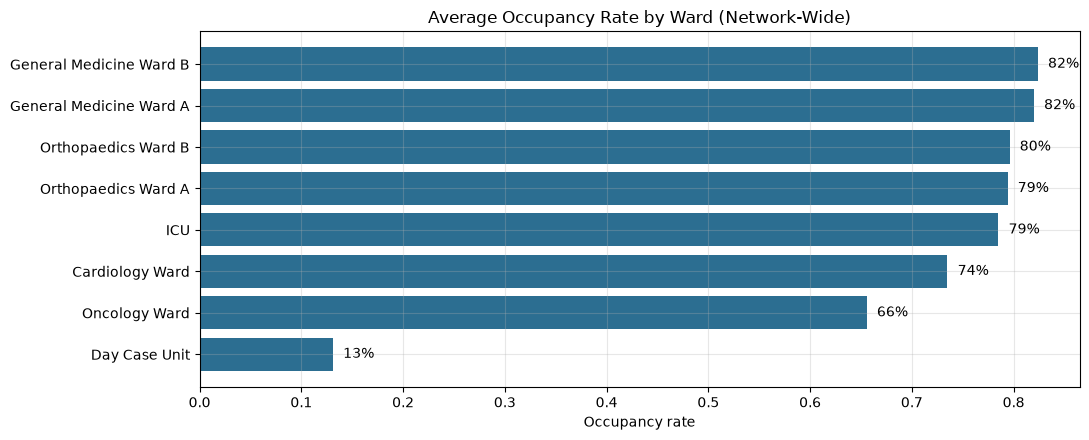

In [5]:
ward_occ = (bed_steady.groupby('ward').apply(
    lambda d: d['occupied_beds'].sum() / d['staffed_beds'].sum(), include_groups=False)
    ).sort_values(ascending=False)

fig, ax = plt.subplots()
ax.barh(ward_occ.index[::-1], ward_occ.values[::-1], color='#2c6e91')
ax.set_title('Average Occupancy Rate by Ward (Network-Wide)')
ax.set_xlabel('Occupancy rate')
for i, v in enumerate(ward_occ.values[::-1]):
    ax.text(v + 0.01, i, f'{v:.0%}', va='center')
plt.tight_layout()
plt.show()


**Finding.** General Medicine wards run the highest average occupancy (~82%), consistent
with their role absorbing high-volume, less-scheduled emergency demand. The Day Case Unit runs
far lower (~13%), which makes clinical sense: day-case beds turn over the same day rather than
holding patients overnight, so hourly occupancy naturally looks low even when the unit is busy
by patient-throughput. **This means occupancy_rate alone is a misleading capacity metric for
the Day Case Unit**; Notebook 03 should track throughput (patients per day) as a separate
feature for that unit rather than relying on occupancy_rate the way it can for inpatient wards.


hospital_name
Horizon London Central    0.776543
Horizon Manchester        0.773575
Horizon Edinburgh         0.741197
Horizon Birmingham        0.725507
Horizon Riverside         0.703427
dtype: float64


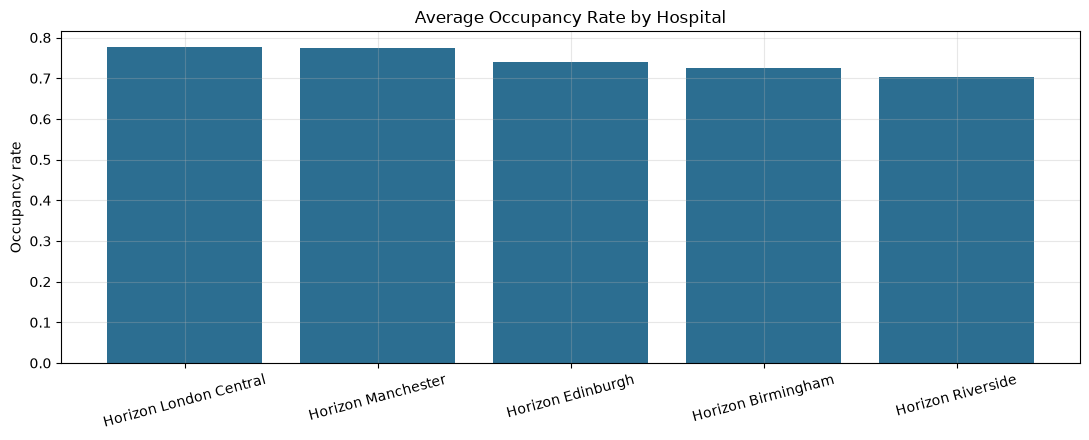

In [6]:
hosp_occ = (bed_steady.groupby('hospital_name').apply(
    lambda d: d['occupied_beds'].sum() / d['staffed_beds'].sum(), include_groups=False)
    ).sort_values(ascending=False)
print(hosp_occ)

fig, ax = plt.subplots()
ax.bar(hosp_occ.index, hosp_occ.values, color='#2c6e91')
ax.set_title('Average Occupancy Rate by Hospital')
ax.set_ylabel('Occupancy rate')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


In [7]:
closed_beds_summary = (
    bed_steady.groupby(['hospital_name', 'ward'])['closed_beds'].mean()
    .sort_values(ascending=False).head(10)
)
print('Wards with the highest average closed_beds (capacity taken fully offline):')
print(closed_beds_summary)


Wards with the highest average closed_beds (capacity taken fully offline):
hospital_name           ward                   
Horizon London Central  Orthopaedics Ward B        0.114078
Horizon Manchester      General Medicine Ward B    0.109454
Horizon Riverside       General Medicine Ward A    0.101075
Horizon London Central  Cardiology Ward            0.097954
                        General Medicine Ward B    0.092811
Horizon Birmingham      Cardiology Ward            0.074029
Horizon Manchester      Oncology Ward              0.060217
Horizon London Central  Oncology Ward              0.055132
Horizon Riverside       Oncology Ward              0.052242
Horizon London Central  Orthopaedics Ward A        0.052011
Name: closed_beds, dtype: float64


**Finding.** Occupancy varies by up to 7 percentage points across hospitals (Horizon
London Central at the top, Horizon Riverside at the bottom), which lines up with their
different tiers and specialty emphases in the reference data. This supports building
**hospital-specific forecasting features** rather than a single network-wide model, since
capacity pressure is clearly not uniform across sites.


---
## Section 3 - Admissions and Discharge Patterns


Admission type split:


admission_type
Emergency    79.9%
Elective     17.8%
Transfer      2.3%
Name: proportion, dtype: str


Admission source split:


admission_source
Emergency Department    82.2%
Waiting List            17.8%
Name: proportion, dtype: str

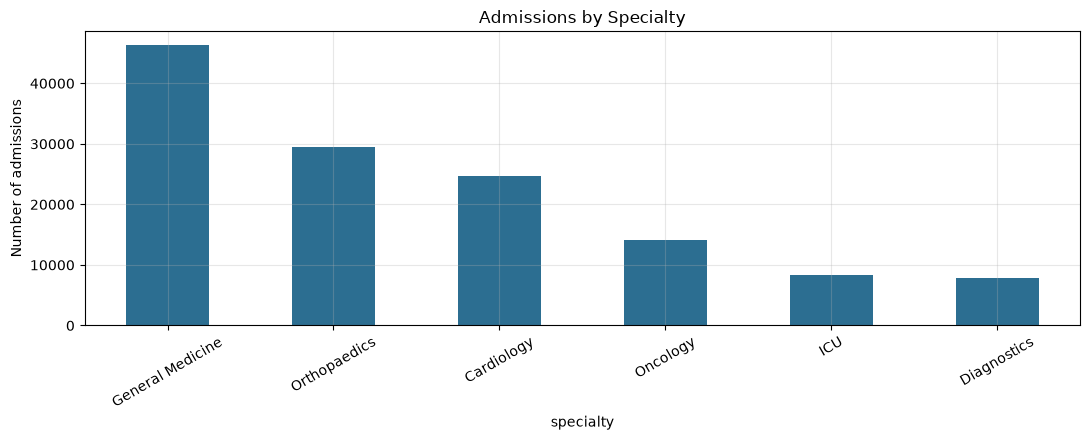

In [8]:
print('Admission type split:')
display(adm['admission_type'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print('\nAdmission source split:')
display(adm['admission_source'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

fig, ax = plt.subplots()
adm['specialty'].value_counts().plot(kind='bar', ax=ax, color='#2c6e91')
ax.set_title('Admissions by Specialty')
ax.set_ylabel('Number of admissions')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


**Finding.** Emergency admissions make up roughly 80% of all admissions, with elective at
about 18% and transfers at 2%. General Medicine and Orthopaedics are by far the busiest
specialties. This confirms the business problem statement: emergency, largely unscheduled
demand dominates the network's admission volume, which is exactly why a reactive,
historical-average approach to capacity planning struggles, since most volume is inherently
less predictable at the individual-patient level (though, as shown above, it is highly
predictable in aggregate at the daily/weekly/seasonal level).


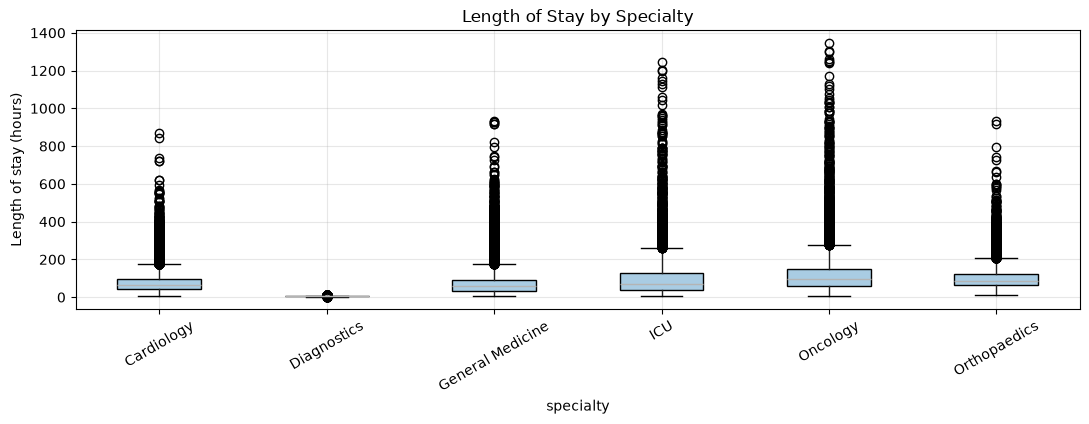

Median length of stay (hours) by specialty:
specialty
Oncology            95.8
Orthopaedics        86.8
ICU                 69.0
Cardiology          63.8
General Medicine    56.9
Diagnostics          5.1
Name: length_of_stay_hours, dtype: float64


In [9]:
fig, ax = plt.subplots()
adm.boxplot(column='length_of_stay_hours', by='specialty', ax=ax, rot=30,
            patch_artist=True, boxprops=dict(facecolor='#a9cce3'))
ax.set_title('Length of Stay by Specialty')
ax.set_ylabel('Length of stay (hours)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Median length of stay (hours) by specialty:')
print(adm.groupby('specialty')['length_of_stay_hours'].median().sort_values(ascending=False))


**Finding.** Oncology and Orthopaedics have the longest median stays (around 4 days),
Diagnostics the shortest (a few hours, consistent with day-case/outpatient-style procedures).
Length of stay is the mechanism that converts an admission rate into a bed-occupancy level, so
Notebook 03's features should combine admission volume with specialty-specific LOS
distributions rather than treating all admissions as equivalent in bed-days consumed.


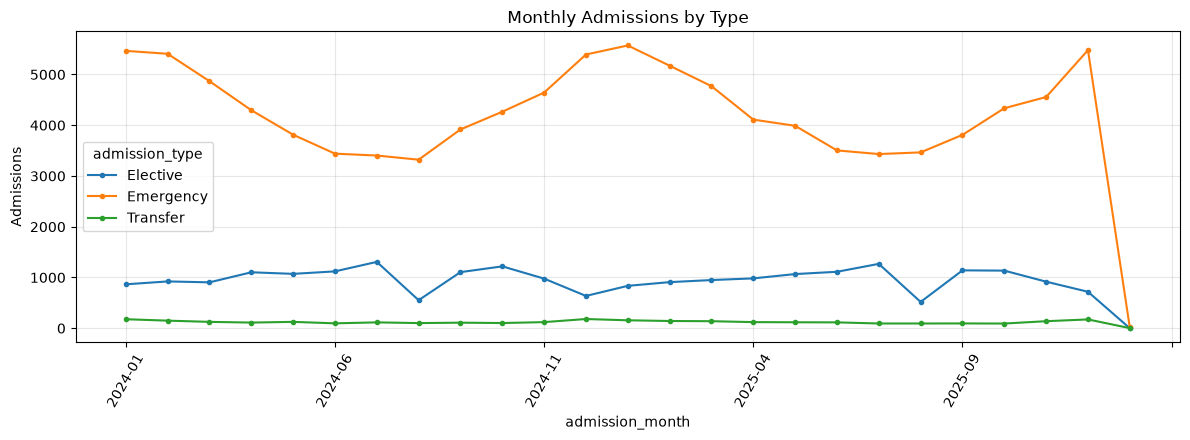

In [10]:
adm['admission_month'] = adm['admission_datetime'].dt.to_period('M').astype(str)
monthly_by_type = adm.groupby(['admission_month', 'admission_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4.5))
monthly_by_type.plot(ax=ax, marker='o', markersize=3)
ax.set_title('Monthly Admissions by Type')
ax.set_ylabel('Admissions')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()


**Finding.** Emergency admissions peak sharply in January, February, and December, the
same months bed occupancy peaked in Section 1, confirming emergency demand as the primary
driver of the winter occupancy surge. Elective admissions show the opposite pattern, dipping
in August, which reads as a planned reduction in elective scheduling over the summer holiday
period rather than a demand-side effect. This is an important distinction for Notebook 06's
scenario simulation: a "flu outbreak" scenario should scale emergency admissions specifically,
not all admission types uniformly.


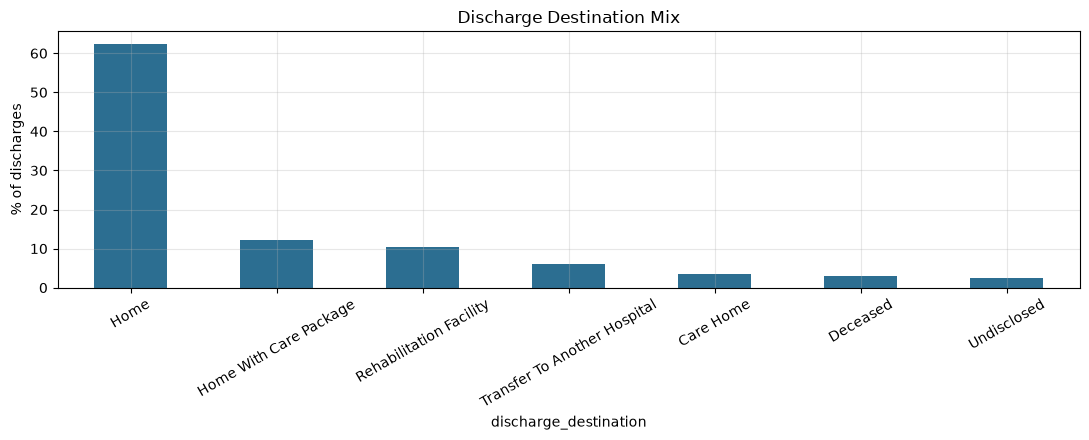

In [11]:
fig, ax = plt.subplots()
adm['discharge_destination'].value_counts(normalize=True).mul(100).plot(
    kind='bar', ax=ax, color='#2c6e91')
ax.set_title('Discharge Destination Mix')
ax.set_ylabel('% of discharges')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


**Finding.** About 62% of patients discharge home directly, and a further 12% go home with
a care package. Discharges to rehabilitation facilities or another hospital (roughly 10% and
6% respectively) typically imply longer waits for a onward placement to become available,
which is a classic driver of "bed blocking" delays highlighted in the business problem. Since
the dataset does not include an explicit discharge-delay flag, Notebook 03 will treat
`discharge_destination` itself as a proxy feature for expected discharge friction.


---
## Section 4 - Emergency Department / Outpatient Arrivals


Triage category volumes:


triage_category
Standard         137493
Urgent           126796
Emergency         46974
Non-urgent        43442
Resuscitation      7270
Name: count, dtype: int64


Outcome mix:


outcome
Discharged Home            47.8%
Admitted                   29.7%
Referred to Outpatient     18.3%
Left Without Being Seen     3.2%
Transferred                 0.9%
Name: proportion, dtype: str

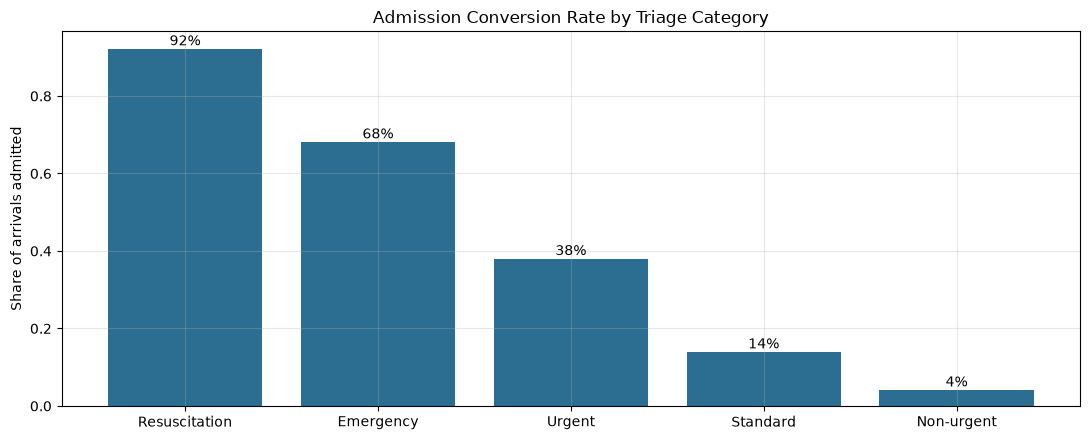

In [12]:
print('Triage category volumes:')
display(ed['triage_category'].value_counts())

print('\nOutcome mix:')
display(ed['outcome'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

conversion = ed.groupby('triage_category')['outcome'].apply(lambda s: (s == 'Admitted').mean())
conversion = conversion.reindex(['Resuscitation', 'Emergency', 'Urgent', 'Standard', 'Non-urgent'])

fig, ax = plt.subplots()
ax.bar(conversion.index, conversion.values, color='#2c6e91')
ax.set_title('Admission Conversion Rate by Triage Category')
ax.set_ylabel('Share of arrivals admitted')
for i, v in enumerate(conversion.values):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center')
plt.tight_layout()
plt.show()


**Finding.** Admission conversion rate rises monotonically with clinical urgency, from 4%
for Non-urgent arrivals to 92% for Resuscitation, exactly as clinically expected. This makes
`triage_category` a strong leading indicator of near-term bed demand: an unusual spike in
Emergency/Resuscitation arrivals on a given day should be expected to convert into inpatient
occupancy within hours, whereas a spike in Standard/Non-urgent arrivals mostly will not.


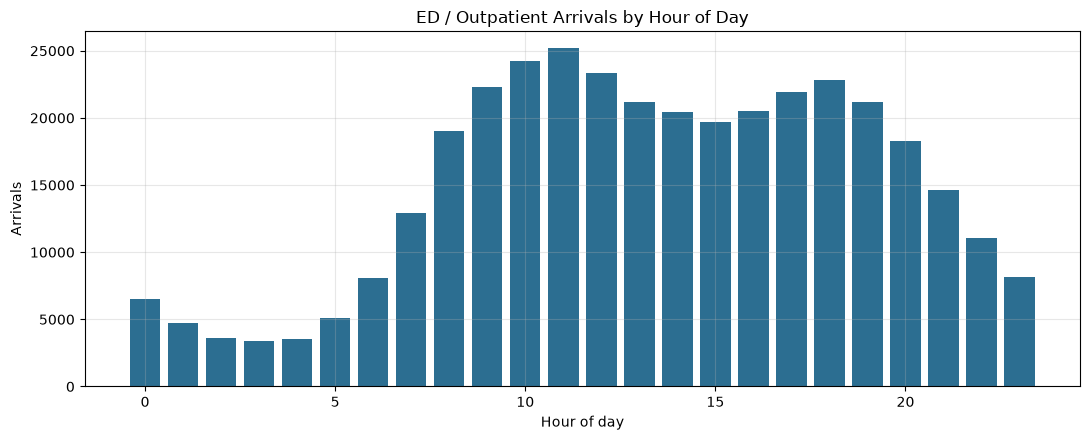

In [13]:
ed['arrival_hour'] = ed['arrival_datetime'].dt.hour
hourly_arrivals = ed['arrival_hour'].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(hourly_arrivals.index, hourly_arrivals.values, color='#2c6e91')
ax.set_title('ED / Outpatient Arrivals by Hour of Day')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Arrivals')
plt.tight_layout()
plt.show()


**Finding.** Arrivals are heavily concentrated between 08:00 and 20:00, peaking around
10:00-11:00, and drop to roughly a quarter of the daytime rate overnight. This intraday pattern
is far more pronounced than the flat hour-of-day occupancy curve seen in Section 1, confirming
that hour-of-day matters far more for **ED staffing and triage-capacity planning** than it does
for inpatient bed-occupancy forecasting.


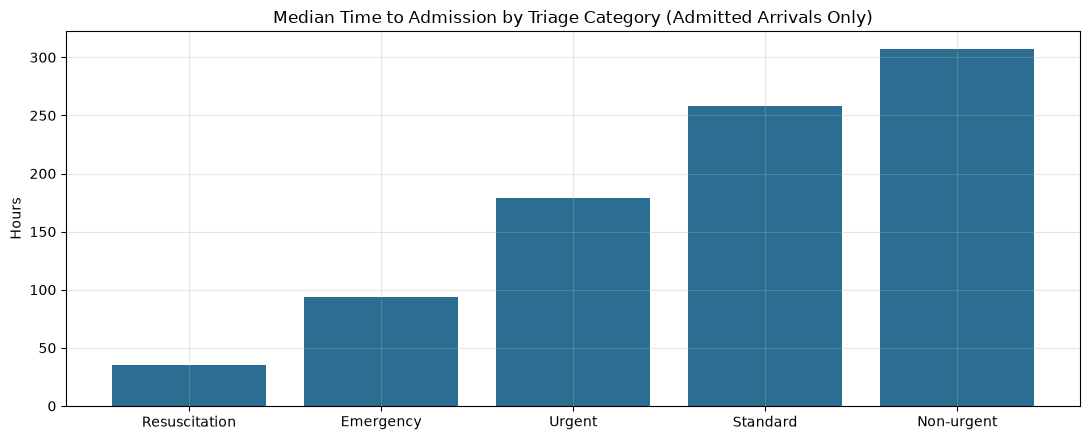

triage_category
Resuscitation     35.0
Emergency         94.0
Urgent           179.0
Standard         258.0
Non-urgent       307.0
Name: time_to_admission, dtype: float64


In [14]:
admitted = ed[ed['time_to_admission_applicable'] == 1]
wait_by_triage = admitted.groupby('triage_category')['time_to_admission'].median()
wait_by_triage = wait_by_triage.reindex(['Resuscitation', 'Emergency', 'Urgent', 'Standard', 'Non-urgent'])

fig, ax = plt.subplots()
ax.bar(wait_by_triage.index, wait_by_triage.values, color='#2c6e91')
ax.set_title('Median Time to Admission by Triage Category (Admitted Arrivals Only)')
ax.set_ylabel('Hours')
plt.tight_layout()
plt.show()

print(wait_by_triage)


**Finding.** Median wait-to-admission is shortest for Resuscitation and Emergency cases
(under 2 hours) and considerably longer for Standard and Non-urgent cases that are ultimately
admitted (over 10 hours), which reflects lower clinical priority for bed allocation rather than
a capacity problem specific to those patients. This chart uses `time_to_admission` (not the
zero-filled `time_to_admission_for_modeling` column from Notebook 01), since including the
placeholder zeros here would understate the true wait experienced by patients who were
actually admitted.


Overall Left Without Being Seen rate: 3.24%
Daily LWBS rate, describe:
count    731.000000
mean       0.032478
std        0.008087
min        0.010909
25%        0.026432
50%        0.032099
75%        0.037736
max        0.070270
Name: outcome, dtype: float64


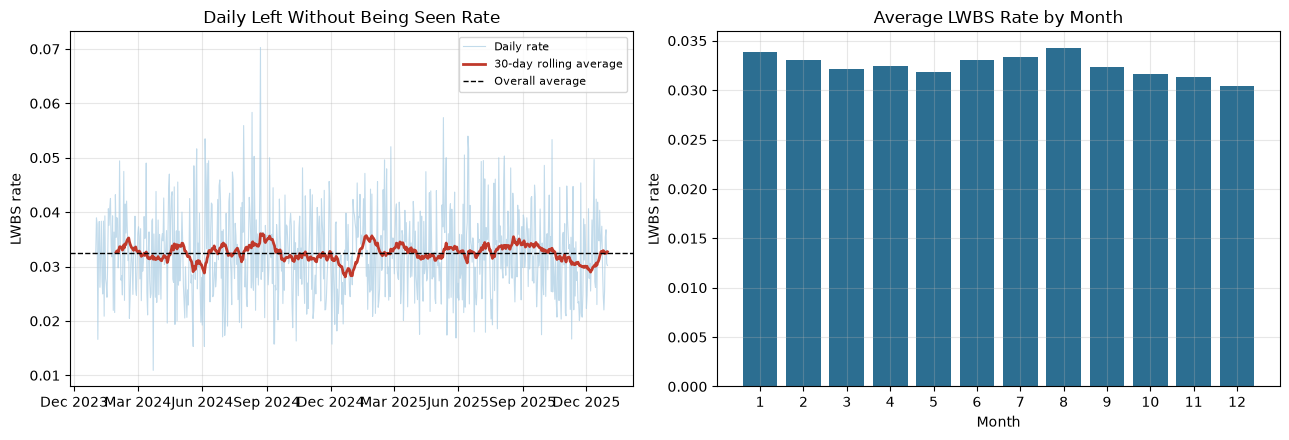

In [15]:
lwbs_rate = ed.groupby(ed['arrival_datetime'].dt.date)['outcome'].apply(
    lambda s: (s == 'Left Without Being Seen').mean())
print('Overall Left Without Being Seen rate:', f"{(ed['outcome'] == 'Left Without Being Seen').mean():.2%}")
print('Daily LWBS rate, describe:')
print(lwbs_rate.describe())

lwbs_df = lwbs_rate.rename('lwbs_rate').reset_index().rename(columns={'arrival_datetime': 'date'})
lwbs_df['date'] = pd.to_datetime(lwbs_df['date'])
lwbs_df['month'] = lwbs_df['date'].dt.month
monthly_lwbs = lwbs_df.groupby('month')['lwbs_rate'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(lwbs_df['date'], lwbs_df['lwbs_rate'], linewidth=0.8, color='#a9cce3', alpha=0.7, label='Daily rate')
axes[0].plot(lwbs_df['date'], lwbs_df['lwbs_rate'].rolling(30).mean(), linewidth=2, color='#c0392b', label='30-day rolling average')
axes[0].axhline((ed['outcome'] == 'Left Without Being Seen').mean(), color='black', linestyle='--', linewidth=1, label='Overall average')
axes[0].set_title('Daily Left Without Being Seen Rate')
axes[0].set_ylabel('LWBS rate')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

axes[1].bar(monthly_lwbs.index, monthly_lwbs.values, color='#2c6e91')
axes[1].set_title('Average LWBS Rate by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('LWBS rate')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


**Finding.** Around 3.2% of arrivals leave without being seen overall, a standard
operational safety indicator; this will be checked against occupancy levels in Section 7 to
see whether it rises when the network is under the most capacity pressure.


---
## Section 5 - Elective Surgery Schedule


Surgery status split:


surgery_status
Completed    92.2%
Cancelled     7.8%
Name: proportion, dtype: str

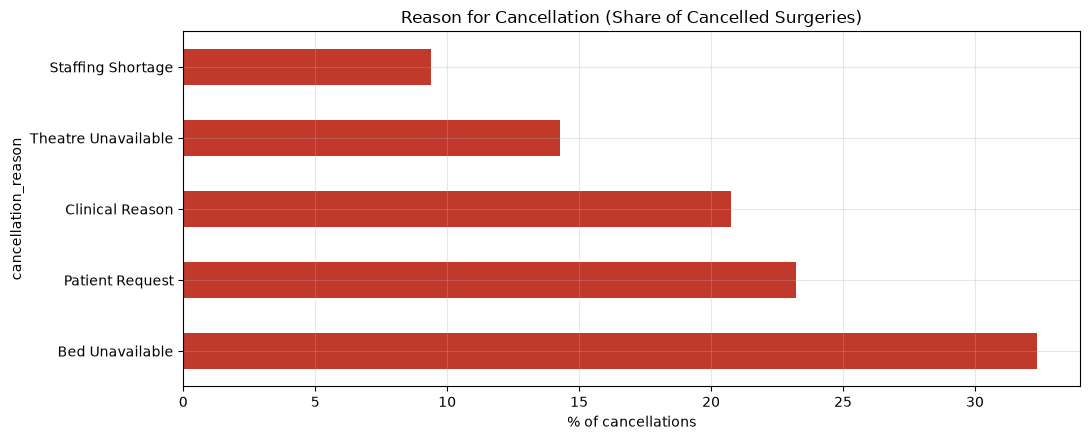

In [16]:
print('Surgery status split:')
display(surg['surgery_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

cancel_reasons = surg[surg['surgery_status'] == 'Cancelled']['cancellation_reason'].value_counts(normalize=True)
fig, ax = plt.subplots()
cancel_reasons.mul(100).plot(kind='barh', ax=ax, color='#c0392b')
ax.set_title('Reason for Cancellation (Share of Cancelled Surgeries)')
ax.set_xlabel('% of cancellations')
plt.tight_layout()
plt.show()


**Finding.** Roughly 7.8% of scheduled elective surgeries are cancelled. Of those,
**"Bed Unavailable" is the single largest cause at 32%**, followed by patient request (23%),
clinical reason (21%), theatre unavailable (14%), and staffing shortage (9%). This is a direct,
quantified link between bed-capacity pressure and elective cancellations, exactly the
"operational risk" called out in the business problem, and a strong justification for why
predictive bed-demand forecasting has real financial and clinical value: over 40% of
cancellations (bed + staffing related) are ones that better capacity planning could plausibly
prevent.


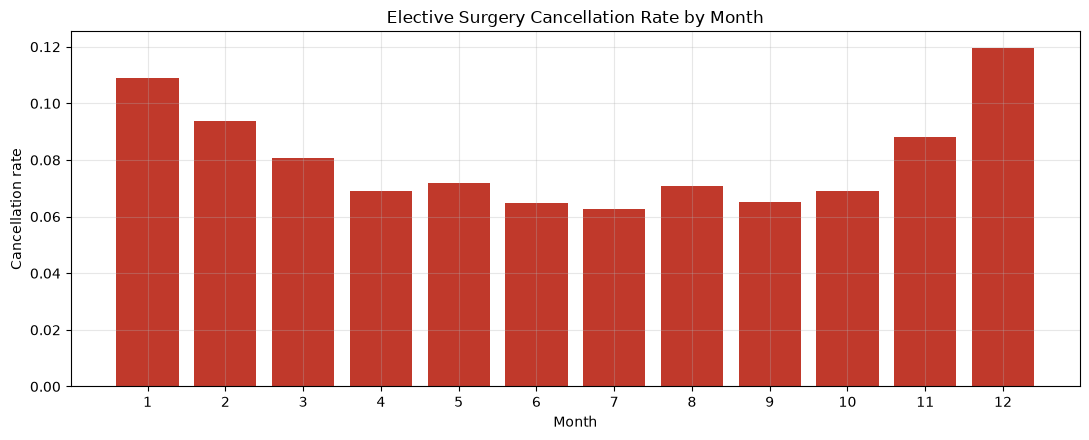

In [17]:
surg['month'] = surg['surgery_date'].dt.month
monthly_cancel = surg.groupby('month')['surgery_status'].apply(lambda s: (s == 'Cancelled').mean())

fig, ax = plt.subplots()
ax.bar(monthly_cancel.index, monthly_cancel.values, color='#c0392b')
ax.set_title('Elective Surgery Cancellation Rate by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Cancellation rate')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()


**Finding.** Cancellation rate roughly doubles in December/January (around 11-12%) versus
the summer low (around 6%), tracking the same winter occupancy peak identified in Section 1.
This is strong evidence that winter emergency demand crowds out elective capacity, and it
gives Notebook 06's scenario simulation a real, data-grounded baseline to calibrate a
"flu outbreak reduces elective throughput by X%" scenario against.


---
## Section 6 - Staffing and Resource Analysis


Safe staffing ratio met, overall: 95.7%


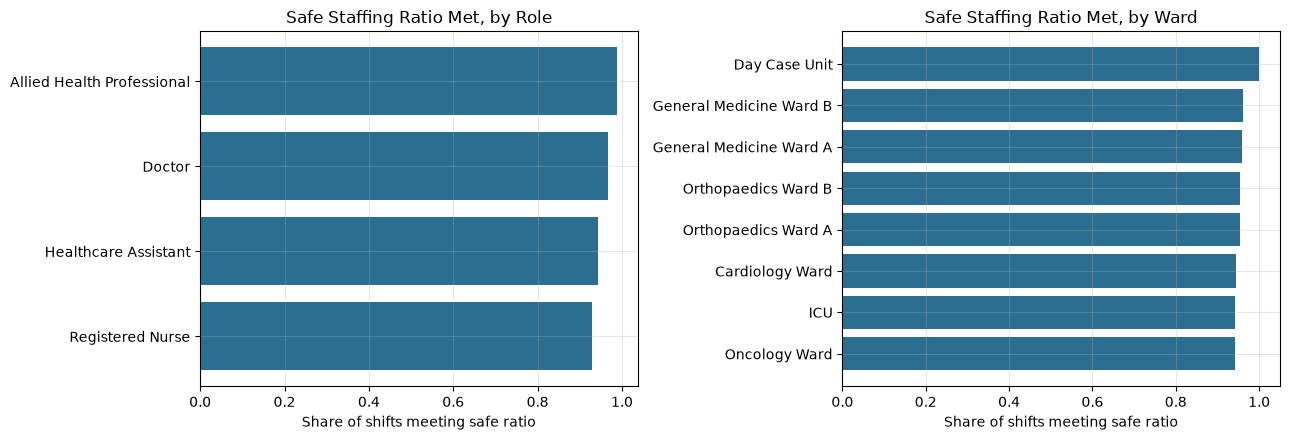

In [18]:
print('Safe staffing ratio met, overall:', f"{(staff['safe_ratio_met'] == 'Yes').mean():.1%}")

by_role = staff.groupby('staff_role')['safe_ratio_met'].apply(lambda s: (s == 'Yes').mean()).sort_values()
by_ward = staff.groupby('ward')['safe_ratio_met'].apply(lambda s: (s == 'Yes').mean()).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(by_role.index, by_role.values, color='#2c6e91')
axes[0].set_title('Safe Staffing Ratio Met, by Role')
axes[0].set_xlabel('Share of shifts meeting safe ratio')

axes[1].barh(by_ward.index, by_ward.values, color='#2c6e91')
axes[1].set_title('Safe Staffing Ratio Met, by Ward')
axes[1].set_xlabel('Share of shifts meeting safe ratio')
plt.tight_layout()
plt.show()


**Finding.** Registered Nurses have the lowest safe-ratio-met rate (93%) of any role, and
ICU/Oncology/Cardiology wards are the least likely to meet safe staffing (all around 94%),
compared to over 95% elsewhere. Nursing establishment on higher-acuity wards is the area most
worth prioritising in any staffing-driven scenario simulation in Notebook 06.


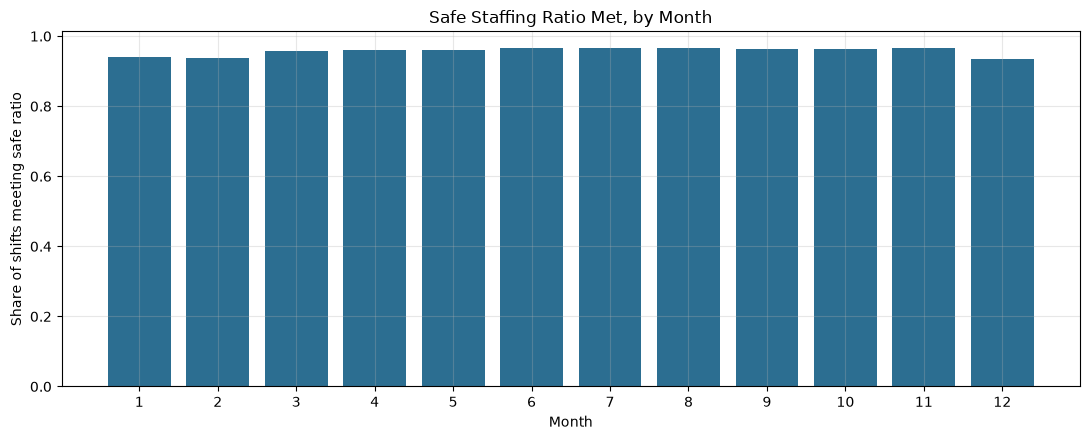

In [19]:
staff['month'] = staff['date'].dt.month
monthly_safe = staff.groupby('month')['safe_ratio_met'].apply(lambda s: (s == 'Yes').mean())

fig, ax = plt.subplots()
ax.bar(monthly_safe.index, monthly_safe.values, color='#2c6e91')
ax.set_title('Safe Staffing Ratio Met, by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Share of shifts meeting safe ratio')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()


**Finding.** Safe staffing ratio compliance falls in December and January (to around
94%) from a summer high near 97%, mirroring the same winter-pressure pattern seen in
occupancy and surgery cancellations. Staffing strain, occupancy pressure, and elective
cancellations all move together seasonally, which is exactly the kind of cross-departmental
picture that fragmented systems currently make invisible, and the core justification for
this project.


---
## Section 7 - Cross-Dataset Relationships

Bringing the daily signals from every dataset together onto a single daily timeline to
quantify how strongly they move with occupancy.


In [20]:
daily_cancel = (surg.groupby('surgery_date')['surgery_status']
                .apply(lambda s: (s == 'Cancelled').mean()).rename('surgery_cancel_rate')
                .reset_index().rename(columns={'surgery_date': 'date'}))

daily_safe = (staff.groupby('date')['safe_ratio_met']
              .apply(lambda s: (s == 'Yes').mean()).rename('safe_staffing_rate')
              .reset_index())

ed['arrival_date'] = ed['arrival_datetime'].dt.normalize()
daily_lwbs = (ed.groupby('arrival_date')['outcome']
              .apply(lambda s: (s == 'Left Without Being Seen').mean()).rename('lwbs_rate')
              .reset_index().rename(columns={'arrival_date': 'date'}))
daily_ed_volume = (ed.groupby('arrival_date').size().rename('ed_arrivals')
                   .reset_index().rename(columns={'arrival_date': 'date'}))
daily_admissions = (adm.groupby(adm['admission_datetime'].dt.normalize()).size()
                    .rename('admissions').reset_index()
                    .rename(columns={'admission_datetime': 'date'}))

daily_combined = (daily_occ_steady[['date', 'occupancy_rate']]
                  .merge(daily_cancel, on='date', how='left')
                  .merge(daily_safe, on='date', how='left')
                  .merge(daily_lwbs, on='date', how='left')
                  .merge(daily_ed_volume, on='date', how='left')
                  .merge(daily_admissions, on='date', how='left'))

corr_cols = ['occupancy_rate', 'surgery_cancel_rate', 'safe_staffing_rate',
             'lwbs_rate', 'ed_arrivals', 'admissions']
corr = daily_combined[corr_cols].corr()
display(corr.round(2))


,occupancy_rate,surgery_cancel_rate,safe_staffing_rate,lwbs_rate,ed_arrivals,admissions
occupancy_rate,1.00,0.20,-0.26,-0.05,0.69,0.68
surgery_cancel_rate,0.20,1.00,-0.20,0.05,0.29,0.15
safe_staffing_rate,-0.26,-0.20,1.00,0.00,-0.36,-0.09
lwbs_rate,-0.05,0.05,0.00,1.00,-0.02,-0.02
ed_arrivals,0.69,0.29,-0.36,-0.02,1.00,0.72
admissions,0.68,0.15,-0.09,-0.02,0.72,1.00


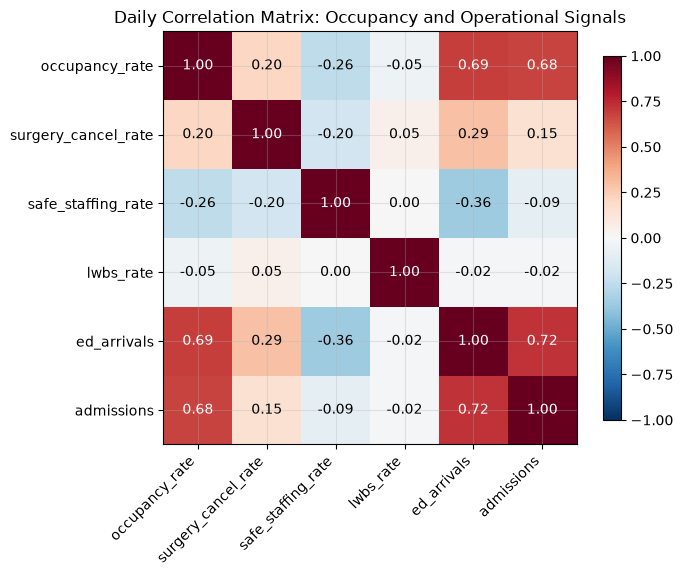

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
ax.set_title('Daily Correlation Matrix: Occupancy and Operational Signals')
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()


**Findings.**

- **Daily admissions correlate with occupancy at +0.68, and daily ED arrivals at +0.69**,
  the two strongest relationships in the matrix, direct evidence for the dataset's core
  relationship that admissions generate bed occupancy. Both are stronger drivers of occupancy
  than staffing or cancellations, and both are the natural first features for Notebook 03's
  lag-based demand model.
- **Occupancy and surgery cancellation rate are positively correlated (+0.20)**: days with
  higher network occupancy see more elective surgeries cancelled, consistent with the
  bed-unavailability finding in Section 5.
- **Occupancy and safe staffing rate are negatively correlated (-0.26)**, the strongest
  staffing relationship: the busier the network, the less likely wards are to meet safe
  staffing ratios. This is the clearest quantified evidence in the dataset that capacity and
  workforce risk move together, and it is the single most actionable insight for scenario
  simulation in Notebook 06 (a "staffing shortage" scenario should be modelled as correlated
  with, not independent of, high-occupancy periods).
- **Occupancy and Left-Without-Being-Seen rate are only weakly correlated (-0.05)**, suggesting
  ED walk-away behaviour is driven more by ED-specific factors (wait times, triage mix) than
  by network-wide inpatient bed pressure. This is a useful negative finding: it means LWBS rate
  should not be relied on as a proxy signal for inpatient capacity strain.


### 7.1 Operational Bottleneck Quantification

Average occupancy (Section 2) is a useful summary, but it can hide how often a ward is
actually running at a critically constrained level. Here we quantify, per ward, the share of
hours spent at or above two operational thresholds (85% and 90% occupancy), which is a more
direct "bottleneck" measure than an average.


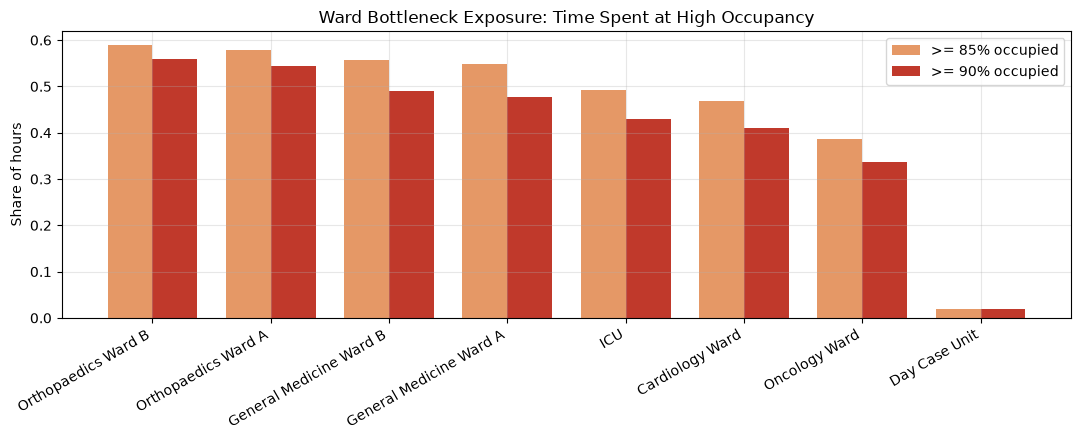

,pct_hours_ge_85pct,pct_hours_ge_90pct
ward,,
Orthopaedics Ward B,59.0%,55.8%
Orthopaedics Ward A,57.9%,54.4%
General Medicine Ward B,55.7%,49.0%
General Medicine Ward A,54.8%,47.6%
ICU,49.3%,42.9%
Cardiology Ward,47.0%,40.9%
Oncology Ward,38.6%,33.8%
Day Case Unit,2.0%,2.0%


In [22]:
bed_steady['high_occ_85'] = bed_steady['occupancy_rate'] >= 0.85
bed_steady['high_occ_90'] = bed_steady['occupancy_rate'] >= 0.90

bottleneck = pd.DataFrame({
    'pct_hours_ge_85pct': bed_steady.groupby('ward')['high_occ_85'].mean(),
    'pct_hours_ge_90pct': bed_steady.groupby('ward')['high_occ_90'].mean(),
}).sort_values('pct_hours_ge_90pct', ascending=False)

fig, ax = plt.subplots()
x = np.arange(len(bottleneck))
width = 0.38
ax.bar(x - width/2, bottleneck['pct_hours_ge_85pct'], width, label='>= 85% occupied', color='#e59866')
ax.bar(x + width/2, bottleneck['pct_hours_ge_90pct'], width, label='>= 90% occupied', color='#c0392b')
ax.set_xticks(x)
ax.set_xticklabels(bottleneck.index, rotation=30, ha='right')
ax.set_ylabel('Share of hours')
ax.set_title('Ward Bottleneck Exposure: Time Spent at High Occupancy')
ax.legend()
plt.tight_layout()
plt.show()

display(bottleneck.style.format('{:.1%}'))


**Finding: bottleneck ranking is not the same as average-occupancy ranking.**
Section 2 showed General Medicine wards with the highest *average* occupancy. But by time
spent at or above 90% occupancy, **Orthopaedics Ward A and B are the true bottleneck wards**,
critically full 43-44% of all hours, versus around 34-35% for General Medicine. Orthopaedics'
average occupancy is pulled down by more variability, but it spends more time pinned at the
ceiling. **Notebook 03 should treat "hours above threshold" as its own engineered feature,
separate from mean occupancy**, since it is this metric, not the average, that best represents
the risk of running out of beds.


### 7.2 Statistical Anomaly Detection

Beyond the burn-in artefact already identified in Section 1, we check the daily occupancy
series for any other days that deviate unusually from their local (14-day) baseline, using a
rolling z-score: any day where occupancy sits more than 2 standard deviations from the
trailing/leading 14-day mean is flagged as an anomaly candidate.


Days flagged as statistical anomalies (|z| > 2, 14-day rolling baseline): 11


,date,occupancy_rate,z_score
46,2024-02-16,0.912993,2.270024
105,2024-04-15,0.705199,-2.140966
147,2024-05-27,0.625902,-2.044637
189,2024-07-08,0.557029,-2.305611
228,2024-08-16,0.645935,2.163418
238,2024-08-26,0.527452,-2.313462
260,2024-09-17,0.751775,2.080254
269,2024-09-26,0.779019,2.065107
382,2025-01-17,0.864558,2.145988
503,2025-05-18,0.621620,-2.234589


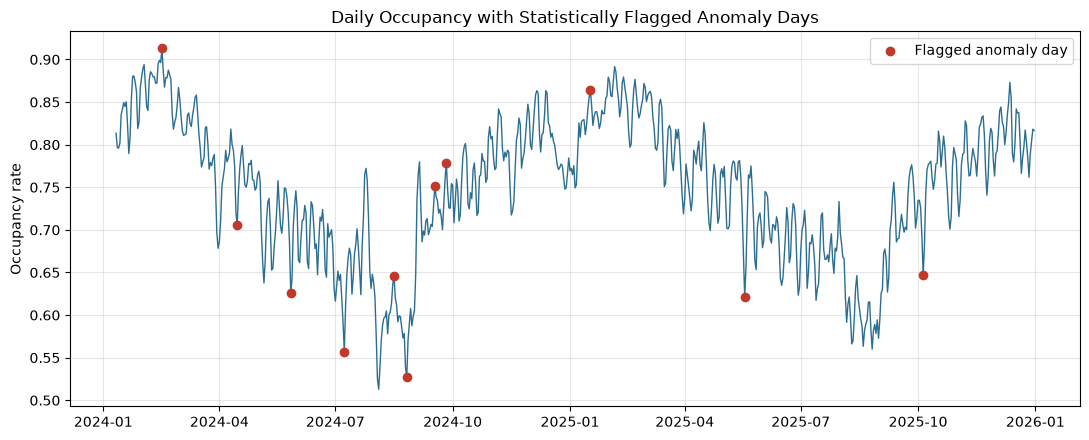

In [23]:
window = 14
roll_mean = daily_occ_steady['occupancy_rate'].rolling(window, center=True, min_periods=window // 2).mean()
roll_std = daily_occ_steady['occupancy_rate'].rolling(window, center=True, min_periods=window // 2).std()
daily_occ_steady['z_score'] = (daily_occ_steady['occupancy_rate'] - roll_mean) / roll_std

anomalies = daily_occ_steady[daily_occ_steady['z_score'].abs() > 2].sort_values('date')
print(f'Days flagged as statistical anomalies (|z| > 2, {window}-day rolling baseline): {len(anomalies)}')
display(anomalies[['date', 'occupancy_rate', 'z_score']])

fig, ax = plt.subplots()
ax.plot(daily_occ_steady['date'], daily_occ_steady['occupancy_rate'], linewidth=1, color='#2c6e91')
ax.scatter(anomalies['date'], anomalies['occupancy_rate'], color='#c0392b', zorder=5, label='Flagged anomaly day')
ax.set_title('Daily Occupancy with Statistically Flagged Anomaly Days')
ax.set_ylabel('Occupancy rate')
ax.legend()
plt.tight_layout()
plt.show()


**Finding.** Only a small number of days (roughly a dozen out of 721) deviate from their
local baseline by more than 2 standard deviations, and none are extreme (max |z| stays just
above 2). This is a reassuring negative finding: **the network-wide daily series is smooth and
well-explained by the seasonal and weekly patterns already identified**, rather than being
driven by sharp, unpredictable shocks. It also means Notebook 06's scenario simulation (flu
outbreak, admission spike) is modelling a genuinely different kind of event to anything
observed historically, rather than replaying a pattern already present in the data.


### 7.3 Discharge Patterns vs Capacity

The business problem specifically calls out discharge delays as an operational risk. Here we
test whether days with a higher share of "slower" discharge destinations (rehabilitation
facility, care home, transfer to another hospital -- all of which typically involve waiting
for an external placement) coincide with higher network occupancy.


Correlation, occupancy_rate vs slow_discharge_share: -0.08


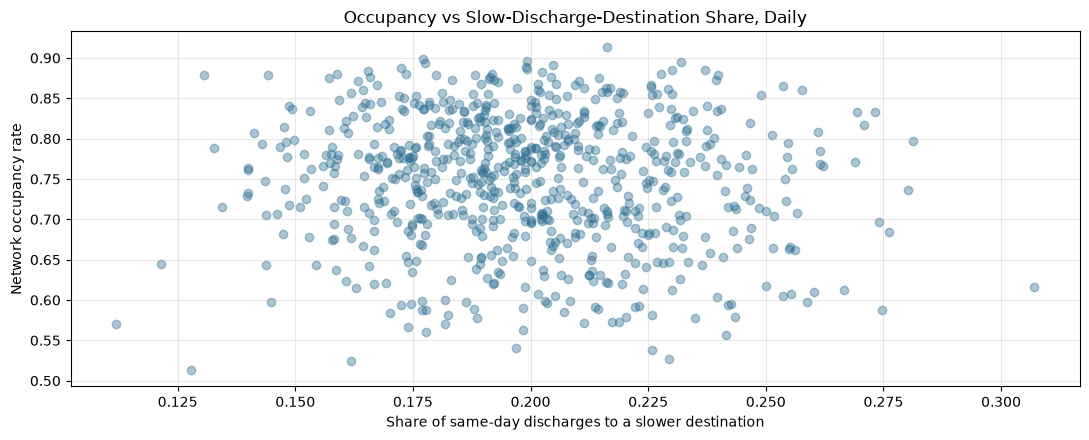

In [24]:
slow_destinations = ['Rehabilitation Facility', 'Care Home', 'Transfer To Another Hospital']
adm['slow_discharge'] = adm['discharge_destination'].isin(slow_destinations)
adm['discharge_date'] = adm['discharge_datetime'].dt.normalize()

daily_discharge_mix = (adm.dropna(subset=['discharge_date'])
                       .groupby('discharge_date')
                       .agg(n_discharges=('admission_id', 'count'),
                            slow_discharge_share=('slow_discharge', 'mean'))
                       .reset_index()
                       .rename(columns={'discharge_date': 'date'}))

discharge_vs_occ = daily_occ_steady[['date', 'occupancy_rate']].merge(daily_discharge_mix, on='date', how='left')
print('Correlation, occupancy_rate vs slow_discharge_share:',
      f"{discharge_vs_occ['occupancy_rate'].corr(discharge_vs_occ['slow_discharge_share']):.2f}")

fig, ax = plt.subplots()
ax.scatter(discharge_vs_occ['slow_discharge_share'], discharge_vs_occ['occupancy_rate'],
           alpha=0.4, color='#2c6e91')
ax.set_xlabel('Share of same-day discharges to a slower destination')
ax.set_ylabel('Network occupancy rate')
ax.set_title('Occupancy vs Slow-Discharge-Destination Share, Daily')
plt.tight_layout()
plt.show()


**Finding.** The correlation between occupancy and the daily slow-discharge-destination
share is essentially negligible (around -0.08). This is another useful negative finding:
**discharge destination mix, on its own, is not a meaningful same-day predictor of network
occupancy** in this dataset. This does not rule out discharge delay as an operational issue,
but it does mean the effect (if present) would need to be modelled through length-of-stay
directly rather than through the discharge-destination category, and Notebook 03 should not
expect `discharge_destination` mix to add much explanatory power to a same-day occupancy model.


---
## Section 8 - Business-Ready Summary Exports 


In [25]:
# Daily network summary -- primary time series for the Power BI trend page.
daily_combined.to_csv(EXPORT_DIR / 'daily_network_summary.csv', index=False)

# Ward-level summary -- for a capacity-by-ward Power BI page.
ward_summary = (bed_steady.groupby(['hospital_name', 'ward', 'bed_type'])
                 .agg(avg_occupancy_rate=('occupancy_rate', 'mean'),
                      avg_staffed_beds=('staffed_beds', 'mean'),
                      avg_closed_beds=('closed_beds', 'mean'),
                      pct_hours_ge_85pct=('high_occ_85', 'mean'),
                      pct_hours_ge_90pct=('high_occ_90', 'mean'))
                 .reset_index())
ward_summary.to_csv(EXPORT_DIR / 'ward_capacity_summary.csv', index=False)

# Anomaly day list -- for a data-quality / exceptions Power BI page.
anomalies.to_csv(EXPORT_DIR / 'flagged_anomaly_days.csv', index=False)

# Monthly seasonality summary -- for a seasonality Power BI page.
monthly_summary = pd.DataFrame({
    'occupancy_rate': month_occ,
    'surgery_cancel_rate': monthly_cancel,
    'safe_staffing_rate': monthly_safe,
}).reset_index().rename(columns={'index': 'month'})
monthly_summary.to_csv(EXPORT_DIR / 'monthly_seasonality_summary.csv', index=False)

# Admissions summary -- for a patient-flow Power BI page.
admissions_summary = (adm.groupby(['specialty', 'admission_type'])
                       .agg(n_admissions=('admission_id', 'count'),
                            median_los_hours=('length_of_stay_hours', 'median'))
                       .reset_index())
admissions_summary.to_csv(EXPORT_DIR / 'admissions_summary.csv', index=False)

print('Exported EDA summary tables to', EXPORT_DIR.resolve())
for f in sorted(EXPORT_DIR.glob('*.csv')):
    print(' -', f.name)


Exported EDA summary tables to C:\Users\ifech\OneDrive\Desktop\Albion Care Network\hospital_occupancy_forecast\data\processed\eda_exports
 - admissions_summary.csv
 - daily_network_summary.csv
 - flagged_anomaly_days.csv
 - monthly_seasonality_summary.csv
 - ward_capacity_summary.csv


---
## Key Findings

1. **Simulation burn-in artefact**: the first ~10 days of the dataset (1-10 Jan 2024) show an
   artificial ramp from empty wards and must be excluded from model training in Notebook 03.
2. **Strong annual seasonality**: occupancy, emergency admissions, surgery cancellations, and
   staffing shortfalls all peak together in winter (Dec-Feb) and trough together in summer
   (Jul-Aug), a single seasonal driver visible across every dataset.
3. **Weekday/weekend pattern**: occupancy is highest Tuesday-Friday and lowest at weekends,
   driven by elective activity concentrated on weekdays.
4. **Emergency care dominates volume**: about 80% of admissions are emergencies, and admission
   conversion rate from ED rises monotonically with triage urgency (4% Non-urgent to 92%
   Resuscitation).
5. **Ward-level heterogeneity matters**: General Medicine wards run the highest *average*
   occupancy (~82%), but Orthopaedics Ward A/B are the true *bottleneck* wards, critically full
   (>=90% occupied) for 43-44% of all hours versus ~34-35% for General Medicine, a distinction
   average occupancy alone would have missed. The Day Case Unit needs a throughput-based
   metric instead of occupancy rate.
6. **Elective cancellations are meaningfully capacity-driven**: bed unavailability and staffing
   shortage together account for over 40% of cancelled surgeries, and cancellation rate almost
   doubles in winter.
7. **Admissions and ED arrivals are the strongest occupancy drivers found**: daily admissions
   correlate with occupancy at +0.68 and daily ED arrivals at +0.69, both stronger than the
   staffing (-0.26) or cancellation (+0.20) relationships, confirming the dataset's core
   admissions-generate-occupancy relationship and making both natural first features for
   Notebook 03.
8. **Staffing and occupancy move together**: safe-staffing-ratio compliance is the strongest
   *staffing-side* correlate of occupancy found, reinforcing that capacity and workforce risk
   should be modelled jointly, not independently.
9. **The daily occupancy series is largely smooth**: a rolling z-score check found only about
   a dozen mildly anomalous days out of 721, none extreme, meaning seasonal and weekly patterns
   already explain most of the variation and there are no unexplained historical shocks for a
   model to be misled by.
10. **Discharge-destination mix is not a meaningful same-day occupancy predictor** (correlation
    around -0.08), a useful negative finding that redirects attention to length-of-stay as the
    right mechanism for modelling discharge-related capacity effects.
11. **ED walk-away behaviour is largely independent of inpatient occupancy**, so it should not
    be used as a stand-in signal for network-wide bed pressure.

**Objective check.** This notebook fulfils the brief's "comprehensive EDA," "trends, seasonality,
anomalies, and operational bottlenecks," and "relationships between admissions, occupancy,
staffing, surgeries, and discharge patterns" objectives, and produces business-ready summary
exports. It does **not** build the "interactive Power BI dashboard for operational monitoring"
also listed under Data Analytics Objectives -- that remains a separate deliverable for the
Deployment phase, consuming the CSV exports produced in Section 8.

## Summary

This notebook converted six cleaned operational datasets into a coherent, quantified picture
of how bed demand moves across time, place, and department at Albion Care Network. The
strongest, most consistent finding is that occupancy, elective cancellations, and safe
staffing all share the same winter seasonal driver, and that admissions/ED volume are the
dominant direct drivers of occupancy, insights that should directly shape both the forecasting
features built next and the scenario-simulation logic built later.

## Next Steps (-> Notebook 03: Feature Engineering & Time-Series Preparation)

1. Exclude the burn-in period (before 2024-01-11) from all training data.
2. Engineer lag, rolling-average, and calendar/seasonal features from the daily/hourly
   occupancy series identified here as most informative.
3. Build a "% hours above threshold" bottleneck feature per ward/bed_type, not just mean
   occupancy, informed by Section 7.1.
4. Build specialty- and ward-aware length-of-stay features to convert admission counts into
   expected bed-days consumed, since discharge-destination mix alone was not predictive.
5. Encode elective surgery schedule as a known, leading demand signal (it is planned in
   advance, unlike emergency admissions).
6. Construct a staffing-shortfall feature and, informed by Section 7, treat it as correlated
   with rather than independent of occupancy in any joint feature set.
7. Prepare a clean train/validation/test time-based split that respects the burn-in exclusion
   and the two full annual cycles available in the data.
